# CP1 — Классификация коммерческой успешности фильмов

В этом ноутбуке собраны основные результаты для **CP1–CP2**:
- описание датасета и источника данных;
- самостоятельная постановка целевой переменной;
- самостоятельный парсинг дополнительного источника данных;
- очистка и подготовка данных;
- обработка выбросов;
- feature engineering;
- EDA;
- baseline и несколько полноценных моделей;
- подбор гиперпараметров;
- сравнение моделей по числовым метрикам;
- выводы и обоснование выбора лучшей модели.

## 1. Импорты и настройка окружения

In [1]:
import ast
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (8, 4)
pd.set_option("display.max_columns", 100)

## 2. Источник данных и описание датасета

### 2.1 Источник данных

В проекте используется датасет о фильмах, загруженный с платформы Kaggle и сохранённый в файле `MOVIES.csv`.

Ссылка на датасет: https://www.kaggle.com/datasets/jacopoferretti/idmb-movies-user-friendly?resource=download

Датасет содержит финансовые, рейтинговые, категориальные и текстовые характеристики фильмов: бюджет, выручку, популярность, пользовательские оценки, язык, жанры, страны, компании-производители и текстовые описания.

Этот источник был выбран, поскольку предоставляет достаточно большой набор наблюдений и позволяет самостоятельно сформулировать ML-задачу — предсказание коммерческой успешности фильма.

### 2.2 Самостоятельный парсинг дополнительного источника

Для выполнения требования по самостоятельному сбору данных в проект добавлен отдельный скрипт `src/data/parse_tmdb_movies.py`. Он собирает дополнительную выборку фильмов через TMDb API, запрашивает детальную информацию по фильмам и сохраняет результат в `data/processed/parsed_tmdb_movies_sample.csv`.

Пример запуска из корня проекта:

```bash
export TMDB_API_KEY=<your_api_key>
python -m src.data.parse_tmdb_movies --pages 3 --output data/processed/parsed_tmdb_movies_sample.csv
```

Основное моделирование ниже выполняется на Kaggle CSV, а результат самостоятельного парсинга используется как дополнительный источник/подтверждение структуры признаков.

### 2.3 Почему выбран этот датасет

Датасет выбран по следующим причинам:
- он удовлетворяет требованиям по объёму;
- содержит признаки разных типов: числовые, категориальные и текстовые;
- позволяет самостоятельно определить таргет коммерческой успешности;
- задача выглядит прикладной и хорошо интерпретируется.

### 2.4 Размер датасета

Ниже проверим размер таблицы, первые строки и типы признаков.

### 2.5 Основные признаки

В датасете есть:
- **числовые признаки**: `budget`, `revenue`, `popularity`, `runtime`, `vote_average`, `vote_count`, `year`;
- **категориальные признаки**: `original_language`, `day_of_week`, `month`, `season`, `has_homepage`, `adult`;
- **текстовые и составные признаки**: `overview`, `tagline`, `genre`, `companies`, `countries`, `belongs_to_collection`.

### Проверка наличия результата самостоятельного парсинга

Если файл `data/processed/parsed_tmdb_movies_sample.csv` уже создан скриптом `src/data/parse_tmdb_movies.py`, ниже можно быстро посмотреть его первые строки. Если файла нет, notebook продолжит работу с основным Kaggle CSV.

In [2]:
parsed_candidates = [
    Path("data/processed/parsed_tmdb_movies_sample.csv"),
    Path("../data/processed/parsed_tmdb_movies_sample.csv"),
]

parsed_path = next((path for path in parsed_candidates if path.exists()), None)
if parsed_path is not None:
    parsed_df = pd.read_csv(parsed_path)
    print("Найден результат самостоятельного парсинга:", parsed_path)
    print("Форма parsed_df:", parsed_df.shape)
    display(parsed_df.head())
else:
    print(
        "Файл самостоятельного парсинга пока не найден. "
        "Для создания запустите: python -m src.data.parse_tmdb_movies "
        "--pages 3 --output data/processed/parsed_tmdb_movies_sample.csv"
    )

Файл самостоятельного парсинга пока не найден. Для создания запустите: python -m src.data.parse_tmdb_movies --pages 3 --output data/processed/parsed_tmdb_movies_sample.csv


In [3]:
candidate_data_paths = [
    Path("MOVIES.csv"),
    Path("data/raw/MOVIES.csv"),
    Path("../data/raw/MOVIES.csv"),
    Path("notebooks/MOVIES.csv"),
]

DATA_PATH = next((path for path in candidate_data_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Не найден MOVIES.csv. Положите файл в data/raw/MOVIES.csv, "
        "в корень проекта или рядом с notebook."
    )

print("Используем файл данных:", DATA_PATH)
df = pd.read_csv(DATA_PATH)

print("Форма датасета:", df.shape)
display(df.head())
print()
df.info()

Используем файл данных: ../data/raw/MOVIES.csv
Форма датасета: (44985, 23)


,adult,belongs_to_collection,budget,original_language,original_title,overview,popularity,release_date,revenue,runtime,tagline,title,vote_average,vote_count,languages,day_of_week,month,season,year,has_homepage,genre,companies,countries
0,False,Toy Story Collection,30000000,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,1995-10-30,373554033.0,81.0,not available,Toy Story,7.7,5415.0,['English'],Monday,Oct,Q4,1995,YES,"['Animation', 'Comedy', 'Family']",['Pixar Animation Studios'],['United States of America']
1,False,not available,65000000,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,1995-12-15,262797249.0,104.0,Roll the dice and unleash the excitement!,Jumanji,6.9,2413.0,"['English', 'Français']",Friday,Dec,Q4,1995,NO,"['Adventure', 'Fantasy', 'Family']","['TriStar Pictures', 'Teitler Film', 'Intersco...",['United States of America']
2,False,Grumpy Old Men Collection,0,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,1995-12-22,0.0,101.0,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,6.5,92.0,['English'],Friday,Dec,Q4,1995,NO,"['Romance', 'Comedy']","['Warner Bros.', 'Lancaster Gate']",['United States of America']
3,False,not available,16000000,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,1995-12-22,81452156.0,127.0,Friends are the people who let you be yourself...,Waiting to Exhale,6.1,34.0,['English'],Friday,Dec,Q4,1995,NO,"['Comedy', 'Drama', 'Romance']",['Twentieth Century Fox Film Corporation'],['United States of America']
4,False,Father of the Bride Collection,0,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,1995-02-10,76578911.0,106.0,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,5.7,173.0,['English'],Friday,Feb,Q1,1995,NO,['Comedy'],"['Sandollar Productions', 'Touchstone Pictures']",['United States of America']



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44985 entries, 0 to 44984
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  44985 non-null  bool   
 1   belongs_to_collection  44985 non-null  object 
 2   budget                 44985 non-null  int64  
 3   original_language      44985 non-null  object 
 4   original_title         44985 non-null  object 
 5   overview               44985 non-null  object 
 6   popularity             44985 non-null  float64
 7   release_date           44985 non-null  object 
 8   revenue                44985 non-null  float64
 9   runtime                44985 non-null  float64
 10  tagline                44985 non-null  object 
 11  title                  44985 non-null  object 
 12  vote_average           44985 non-null  float64
 13  vote_count             44985 non-null  float64
 14  languages              44985 non-null  object 
 15  d

### Краткий вывод по структуре датасета

Датасет содержит **44 985 строк** и **23 столбца**, что удовлетворяет требованиям проекта по объёму данных.  
В нём присутствуют признаки разных типов: числовые, категориальные и текстовые.

По результатам `df.info()` видно, что в таблице есть пропуски в ряде столбцов, поэтому на следующих этапах потребуется очистка данных и обработка missing values.  
Таким образом, датасет подходит для построения таргета коммерческой успешности и обучения моделей классификации.

## 3. Постановка целевой переменной

### 3.1 Как определяется коммерческая успешность

В качестве основы таргета выберем показатель **ROI**:


\[
  ROI = \frac{revenue}{budget}\]


Почему именно ROI:
- абсолютная прибыль сильно зависит от масштаба фильма;
- ROI отражает относительную окупаемость вложений;
- такой показатель лучше описывает именно коммерческую эффективность.

### 3.2 Расчёт таргета

Оставим фильмы, где можно корректно посчитать ROI:
- `budget > 0`;
- `revenue` известно.

После этого посчитаем `roi` и переведём его в 3 класса.

### 3.3 Разбиение на классы

Используем 3 класса:
- `low` — низкая коммерческая успешность;
- `medium` — средняя;
- `high` — высокая.

Разбиение делаем по квантилям, чтобы классы были более сбалансированными.

In [4]:
work_df = df.copy()

# оставляем строки, где можно корректно посчитать ROI
work_df = work_df[(work_df["budget"] > 0) & (work_df["revenue"].notna())].copy()

# считаем ROI
work_df["roi"] = work_df["revenue"] / work_df["budget"]

# qcut по рангу позволяет избежать проблем из-за большого числа одинаковых ROI
work_df["target_class"] = pd.qcut(
    work_df["roi"].rank(method="first"),
    q=3,
    labels=["low", "medium", "high"]
)

print("Форма после расчёта таргета:", work_df.shape)
display(work_df[["budget", "revenue", "roi", "target_class"]].head())

Форма после расчёта таргета: (8855, 25)


,budget,revenue,roi,target_class
0,30000000,373554033.0,12.451801,high
1,65000000,262797249.0,4.043035,high
3,16000000,81452156.0,5.090760,high
5,60000000,187436818.0,3.123947,high
6,58000000,0.0,0.000000,low


В результате была получена целевая переменная target_class, которая отражает уровень коммерческой успешности фильма и принимает одно из трёх значений: low medium или high. Такая постановка хорошо соответствует задаче проекта, поскольку позволяет предсказывать не точное значение сборов, а понятную категорию коммерческого результата.

,count,share_percent
target_class,,
low,2952,33.34
medium,2951,33.33
high,2952,33.34


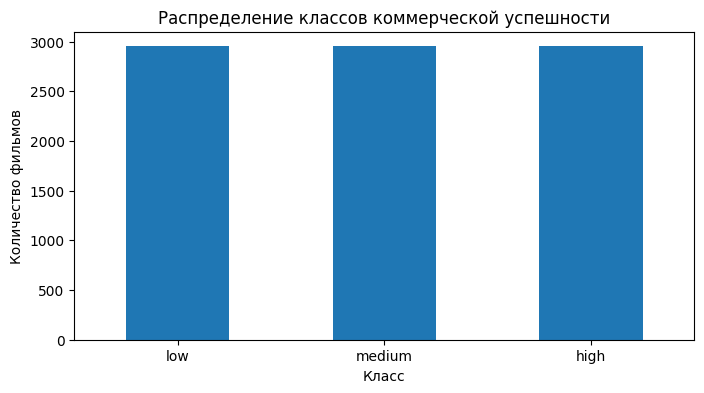

In [5]:
class_counts = work_df["target_class"].value_counts().sort_index()
class_share = work_df["target_class"].value_counts(normalize=True).sort_index().mul(100).round(2)

display(pd.DataFrame({
    "count": class_counts,
    "share_percent": class_share
}))

work_df["target_class"].value_counts().sort_index().plot(kind="bar")
plt.title("Распределение классов коммерческой успешности")
plt.xlabel("Класс")
plt.ylabel("Количество фильмов")
plt.xticks(rotation=0)
plt.show()

В результате получаем многоклассовую задачу классификации.  

## 4. Первичная очистка данных и feature engineering

### Что делаем на этом этапе
- проверяем дубликаты;
- анализируем пропуски;
- приводим даты к типу datetime;
- создаём новые признаки;
- исключаем leakage.

### Важное замечание про leakage

Поскольку таргет построен через `revenue`, этот признак нельзя использовать при обучении модели.  
Иначе модель будет видеть информацию, из которой целевая переменная фактически вычисляется напрямую.

In [6]:
print("Число полных дубликатов:", work_df.duplicated().sum())
print()

missing_table = (
    work_df.isna().sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)
display(missing_table.head(15))

Число полных дубликатов: 0



,missing_count
adult,0
vote_count,0
roi,0
countries,0
companies,0
genre,0
has_homepage,0
year,0
season,0
month,0


In [7]:
work_df["release_date"] = pd.to_datetime(work_df["release_date"], errors="coerce")

def safe_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if not x:
            return []
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass
        return [item.strip() for item in x.split(",") if item.strip()]
    return []

for col in ["genre", "companies", "countries", "languages"]:
    work_df[f"{col}_list"] = work_df[col].apply(safe_list)

# признаки по длинам текстов
work_df["overview_len"] = work_df["overview"].fillna("").str.len()
work_df["tagline_len"] = work_df["tagline"].fillna("").str.len()
work_df["title_len"] = work_df["title"].fillna("").str.len()
work_df["original_title_len"] = work_df["original_title"].fillna("").str.len()

# признаки по числу элементов в списках
work_df["n_genres"] = work_df["genre_list"].apply(len)
work_df["n_companies"] = work_df["companies_list"].apply(len)
work_df["n_countries"] = work_df["countries_list"].apply(len)
work_df["n_languages"] = work_df["languages_list"].apply(len)

# дополнительные бинарные признаки
work_df["is_collection"] = (
    work_df["belongs_to_collection"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
    .astype(int)
)

# признаки по дате
work_df["release_month_num"] = work_df["release_date"].dt.month
work_df["release_day_num"] = work_df["release_date"].dt.day
work_df["release_weekday_num"] = work_df["release_date"].dt.weekday

# логарифмические преобразования для скошенных распределений
for col in ["budget", "popularity", "vote_count", "runtime"]:
    work_df[f"log1p_{col}"] = np.log1p(work_df[col].clip(lower=0))

display(work_df.head())

,adult,belongs_to_collection,budget,original_language,original_title,overview,popularity,release_date,revenue,runtime,tagline,title,vote_average,vote_count,languages,day_of_week,month,season,year,has_homepage,genre,companies,countries,roi,target_class,genre_list,companies_list,countries_list,languages_list,overview_len,tagline_len,title_len,original_title_len,n_genres,n_companies,n_countries,n_languages,is_collection,release_month_num,release_day_num,release_weekday_num,log1p_budget,log1p_popularity,log1p_vote_count,log1p_runtime
0,False,Toy Story Collection,30000000,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,1995-10-30,373554033.0,81.0,not available,Toy Story,7.7,5415.0,['English'],Monday,Oct,Q4,1995,YES,"['Animation', 'Comedy', 'Family']",['Pixar Animation Studios'],['United States of America'],12.451801,high,"[Animation, Comedy, Family]",[Pixar Animation Studios],[United States of America],[English],303,13,9,9,3,1,1,1,1,10.0,30.0,0.0,17.216708,3.133185,8.597113,4.406719
1,False,not available,65000000,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,1995-12-15,262797249.0,104.0,Roll the dice and unleash the excitement!,Jumanji,6.9,2413.0,"['English', 'Français']",Friday,Dec,Q4,1995,NO,"['Adventure', 'Fantasy', 'Family']","['TriStar Pictures', 'Teitler Film', 'Intersco...",['United States of America'],4.043035,high,"[Adventure, Fantasy, Family]","[TriStar Pictures, Teitler Film, Interscope Co...",[United States of America],"[English, Français]",395,41,7,7,3,3,1,2,1,12.0,15.0,4.0,17.989898,2.891235,7.789040,4.653960
3,False,not available,16000000,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,1995-12-22,81452156.0,127.0,Friends are the people who let you be yourself...,Waiting to Exhale,6.1,34.0,['English'],Friday,Dec,Q4,1995,NO,"['Comedy', 'Drama', 'Romance']",['Twentieth Century Fox Film Corporation'],['United States of America'],5.090760,high,"[Comedy, Drama, Romance]",[Twentieth Century Fox Film Corporation],[United States of America],[English],270,78,17,17,3,1,1,1,1,12.0,22.0,4.0,16.588099,1.580935,3.555348,4.852030
5,False,not available,60000000,en,Heat,"Obsessive master thief, Neil McCauley leads a ...",17.924927,1995-12-15,187436818.0,170.0,A Los Angeles Crime Saga,Heat,7.7,1886.0,"['English', 'Español']",Friday,Dec,Q4,1995,NO,"['Action', 'Crime', 'Drama', 'Thriller']","['Regency Enterprises', 'Forward Pass', 'Warne...",['United States of America'],3.123947,high,"[Action, Crime, Drama, Thriller]","[Regency Enterprises, Forward Pass, Warner Bros.]",[United States of America],"[English, Español]",335,24,4,4,4,3,1,2,1,12.0,15.0,4.0,17.909855,2.940480,7.542744,5.141664
6,False,not available,58000000,en,Sabrina,An ugly duckling having undergone a remarkable...,6.677277,1995-12-15,0.0,127.0,You are cordially invited to the most surprisi...,Sabrina,6.2,141.0,"['Français', 'English']",Friday,Dec,Q4,1995,NO,"['Comedy', 'Romance']","['Paramount Pictures', 'Scott Rudin Production...","['Germany', 'United States of America']",0.000000,low,"[Comedy, Romance]","[Paramount Pictures, Scott Rudin Productions, ...","[Germany, United States of America]","[Français, English]",187,68,7,7,2,7,2,2,1,12.0,15.0,4.0,17.875954,2.038265,4.955827,4.852030


### Обработка выбросов

В числовых признаках присутствуют выбросы, особенно в финансовых и рейтинговых показателях (`budget`, `revenue`, `popularity`, `vote_count`).

Полное удаление таких объектов может привести к потере информации, поскольку для фильмов большие значения часто являются естественными.  
Поэтому вместо удаления выбросов используется ограничение экстремальных значений по верхнему квантилю.

In [8]:
numeric_outlier_cols = [
    "budget",
    "popularity",
    "vote_count",
    "runtime"
]

for col in numeric_outlier_cols:
    upper = work_df[col].quantile(0.99)
    work_df[col] = work_df[col].clip(upper=upper)

work_df[numeric_outlier_cols].describe()

,budget,popularity,vote_count,runtime
count,8.855000e+03,8855.000000,8855.000000,8855.000000
mean,2.129019e+07,6.957159,450.181398,104.762507
std,3.225016e+07,5.720848,904.006360,24.381640
min,1.000000e+00,0.000000,0.000000,0.000000
25%,2.000000e+06,2.177818,20.000000,91.000000
50%,8.200000e+06,6.341187,94.000000,101.000000
75%,2.500000e+07,10.033366,409.000000,116.000000
max,1.723000e+08,31.396883,5403.520000,183.000000


## 5. Разведочный анализ данных (EDA)

Посмотрим:
- на распределение ROI;
- на различия между классами по ключевым числовым признакам;
- на агрегированные статистики по таргету.

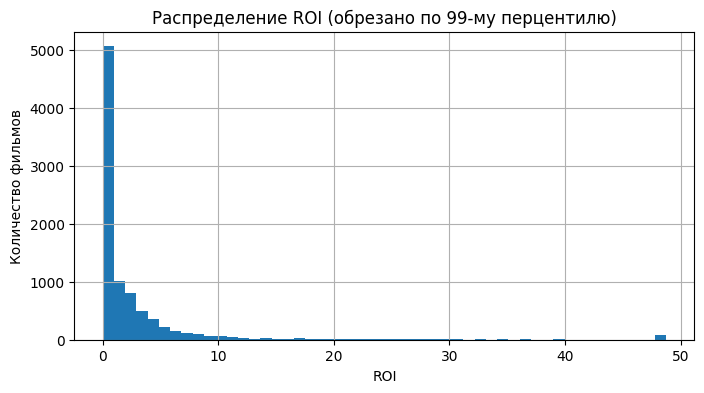

In [9]:
work_df["roi"].clip(upper=work_df["roi"].quantile(0.99)).hist(bins=50)
plt.title("Распределение ROI (обрезано по 99-му перцентилю)")
plt.xlabel("ROI")
plt.ylabel("Количество фильмов")
plt.show()

### Вывод по распределению ROI

Распределение ROI имеет выраженную правую асимметрию: у большинства фильмов окупаемость умеренная, но присутствует небольшое число очень успешных наблюдений с высокими значениями ROI.  
Поэтому удобнее разбить ROI на несколько классов, чтобы сделать задачу более устойчивой и интерпретируемой.

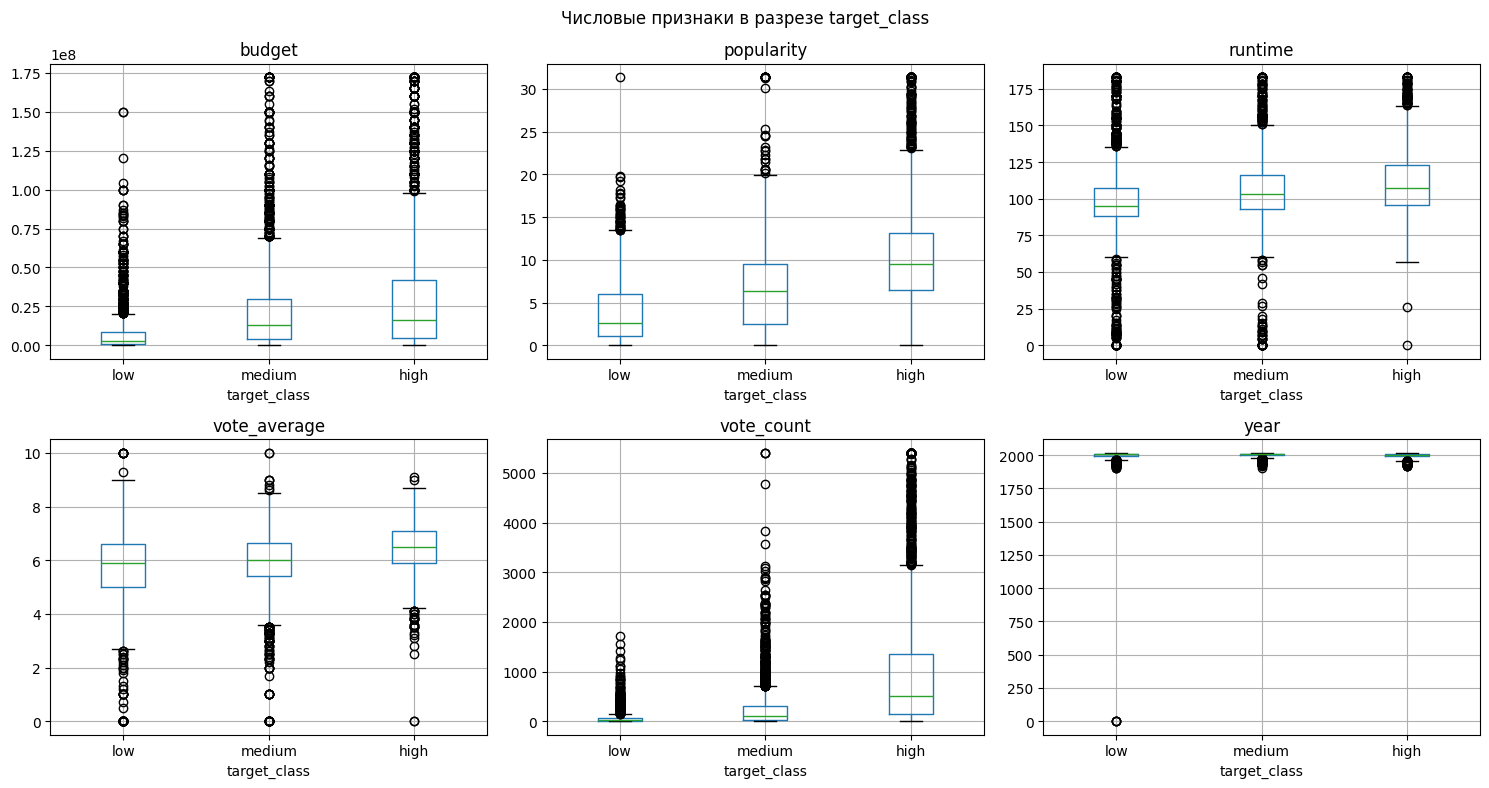

In [10]:
numeric_for_eda = ["budget", "popularity", "runtime", "vote_average", "vote_count", "year"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, numeric_for_eda):
    work_df.boxplot(column=col, by="target_class", ax=ax)
    ax.set_title(col)

plt.suptitle("Числовые признаки в разрезе target_class")
plt.tight_layout()
plt.show()

### Вывод по boxplot признаков

По boxplot видно, что классы коммерческой успешности различаются по нескольким числовым признакам.  
Особенно заметны различия по `budget`, `popularity` и `vote_count`, что указывает на наличие полезного сигнала для будущей классификации.

In [11]:
eda_table = (
    work_df.groupby("target_class")[["budget", "popularity", "runtime", "vote_average", "vote_count"]]
    .median()
    .round(2)
)

display(eda_table)

,budget,popularity,runtime,vote_average,vote_count
target_class,,,,,
low,3000000.0,2.66,95.0,5.9,24.0
medium,13000000.0,6.41,103.0,6.0,97.0
high,16000000.0,9.57,107.0,6.5,512.5


### Вывод по агрегированным статистикам

Медианные значения признаков также подтверждают различия между классами.  
Наиболее успешные фильмы в среднем характеризуются более высокой популярностью, большим количеством голосов и, как правило, более крупным бюджетом. Это делает выбранные признаки полезными для задачи классификации.

## 6. Подготовка признаков для моделирования

Для CP1 используем компактный и воспроизводимый набор признаков.

### Используем
- числовые признаки;
- категориальные признаки;
- engineered features.

### Не используем
- `revenue` и `roi` — это leakage;
- длинные текстовые поля в первой версии моделей не включаем напрямую,  
  но учитываем их через длины текстов.

In [12]:
target_col = "target_class"

numeric_features = [
    "budget", "popularity", "runtime", "vote_average", "vote_count", "year",
    "overview_len", "tagline_len", "title_len", "original_title_len",
    "n_genres", "n_companies", "n_countries", "n_languages", "is_collection",
    "release_month_num", "release_day_num", "release_weekday_num",
    "log1p_budget", "log1p_popularity", "log1p_vote_count", "log1p_runtime"
]

categorical_features = [
    "adult", "original_language", "day_of_week", "month", "season", "has_homepage"
]

model_df = work_df[numeric_features + categorical_features + [target_col]].copy()

X = model_df.drop(columns=[target_col])
y = model_df[target_col]

print("Размер матрицы признаков:", X.shape)
display(X.head())

Размер матрицы признаков: (8855, 28)


,budget,popularity,runtime,vote_average,vote_count,year,overview_len,tagline_len,title_len,original_title_len,n_genres,n_companies,n_countries,n_languages,is_collection,release_month_num,release_day_num,release_weekday_num,log1p_budget,log1p_popularity,log1p_vote_count,log1p_runtime,adult,original_language,day_of_week,month,season,has_homepage
0,30000000.0,21.946943,81.0,7.7,5403.52,1995,303,13,9,9,3,1,1,1,1,10.0,30.0,0.0,17.216708,3.133185,8.597113,4.406719,False,en,Monday,Oct,Q4,YES
1,65000000.0,17.015539,104.0,6.9,2413.00,1995,395,41,7,7,3,3,1,2,1,12.0,15.0,4.0,17.989898,2.891235,7.789040,4.653960,False,en,Friday,Dec,Q4,NO
3,16000000.0,3.859495,127.0,6.1,34.00,1995,270,78,17,17,3,1,1,1,1,12.0,22.0,4.0,16.588099,1.580935,3.555348,4.852030,False,en,Friday,Dec,Q4,NO
5,60000000.0,17.924927,170.0,7.7,1886.00,1995,335,24,4,4,4,3,1,2,1,12.0,15.0,4.0,17.909855,2.940480,7.542744,5.141664,False,en,Friday,Dec,Q4,NO
6,58000000.0,6.677277,127.0,6.2,141.00,1995,187,68,7,7,2,7,2,2,1,12.0,15.0,4.0,17.875954,2.038265,4.955827,4.852030,False,en,Friday,Dec,Q4,NO


### Комментарий по data leakage

При построении модели важно исключить признаки, которые напрямую содержат информацию о целевой переменной.

В проекте таргет строится на основе `ROI = revenue / budget`, поэтому признак `revenue` не используется в обучении.  
Также в признаки не включается `roi`, поскольку он напрямую участвует в определении целевой переменной `target_class`.

Это позволяет избежать прямого leakage, когда модель получает информацию, фактически уже содержащую ответ.

### Почему `budget` оставлен в признаках

Признак `budget` участвует в расчёте ROI, однако сам по себе он не является leakage.  
Бюджет фильма известен до релиза и может использоваться как допустимый предиктор коммерческой успешности.

При этом модель не получает `revenue`, то есть не видит полную информацию, из которой вычисляется таргет.  
Следовательно, использование `budget` является допустимым и соответствует прикладной постановке задачи.

## 7. Train / validation / test split

Данные делим на три части:
- `train` — обучение;
- `validation` — сравнение моделей;
- `test` — финальная оценка лучшей модели.

Используем стратификацию по таргету, чтобы сохранить баланс классов.

In [13]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full,
    test_size=0.25,   # 0.25 от 0.8 = 0.2 от всего датасета
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (5313, 28) (5313,)
Valid: (1771, 28) (1771,)
Test : (1771, 28) (1771,)


In [14]:
split_table = pd.DataFrame({
    "split": ["train", "valid", "test"],
    "n_rows": [len(y_train), len(y_valid), len(y_test)],
    "share": [
        round(len(y_train) / len(y), 3),
        round(len(y_valid) / len(y), 3),
        round(len(y_test) / len(y), 3)
    ]
})
display(split_table)

,split,n_rows,share
0,train,5313,0.6
1,valid,1771,0.2
2,test,1771,0.2


## 8. Метрики и preprocessing

Основная метрика — **macro F1**:
- задача многоклассовая;
- все классы для нас важны;
- macro F1 лучше отражает качество по всем классам, чем обычная accuracy.

Дополнительно смотрим `accuracy`.

In [15]:
numeric_transformer_linear = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_linear = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_linear, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

def to_dense_if_needed(x):
    return x.toarray() if hasattr(x, "toarray") else x

def evaluate_model(name, model, X_train, y_train, X_valid, y_valid):
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_valid = model.predict(X_valid)

    result = {
        "model": name,
        "train_accuracy": round(accuracy_score(y_train, pred_train), 4),
        "valid_accuracy": round(accuracy_score(y_valid, pred_valid), 4),
        "train_macro_f1": round(f1_score(y_train, pred_train, average="macro"), 4),
        "valid_macro_f1": round(f1_score(y_valid, pred_valid, average="macro"), 4),
    }
    return result

## 9. Baseline и первые модели

Для CP1–CP2 сравним baseline и пять полноценных моделей машинного обучения:
1. **DummyClassifier** — наивный baseline, не считается экспериментальной ML-моделью;
2. **LogisticRegression** — базовая линейная модель;
3. **KNeighborsClassifier** — метод ближайших соседей;
4. **DecisionTreeClassifier** — одиночное дерево решений;
5. **RandomForestClassifier** — нелинейный ансамбль деревьев;
6. **HistGradientBoostingClassifier** — градиентный бустинг из `sklearn`.

Таким образом, кроме baseline обучаются 5 полноценных моделей.

In [16]:
dummy_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", DummyClassifier(strategy="most_frequent"))
])

logreg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor_linear),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("to_dense", FunctionTransformer(to_dense_if_needed)),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

hgb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("to_dense", FunctionTransformer(to_dense_if_needed)),
    ("model", HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        max_depth=8
    ))
])

knn_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor_linear),
    ("model", KNeighborsClassifier(n_neighbors=15))
])

dt_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", DecisionTreeClassifier(
        max_depth=10,
        random_state=RANDOM_STATE
    ))
])

In [17]:
results = []

for name, model in [
    ("DummyClassifier", dummy_pipe),
    ("LogisticRegression", logreg_pipe),
    ("KNeighbors", knn_pipe),
    ("DecisionTree", dt_pipe),
    ("RandomForest", rf_pipe),
    ("HistGradientBoosting", hgb_pipe),
]:
    results.append(
        evaluate_model(name, model, X_train, y_train, X_valid, y_valid)
    )

results_df = pd.DataFrame(results).sort_values("valid_macro_f1", ascending=False)
display(results_df)

,model,train_accuracy,valid_accuracy,train_macro_f1,valid_macro_f1
4,RandomForest,0.9912,0.6736,0.9912,0.6687
1,LogisticRegression,0.6354,0.6347,0.6326,0.6324
5,HistGradientBoosting,0.9482,0.6358,0.9482,0.6300
3,DecisionTree,0.7783,0.6064,0.7766,0.5988
2,KNeighbors,0.6358,0.5697,0.6298,0.5625
0,DummyClassifier,0.3333,0.3331,0.1667,0.1666


### Сравнение с baseline

`DummyClassifier` задаёт нижнюю границу качества и показывает, какого результата можно добиться без использования информативных признаков.

В текущем запуске baseline показал:
- `valid_accuracy = 0.3331`;
- `valid_macro_f1 = 0.1666`.

Все обученные модели заметно превосходят baseline, что подтверждает наличие полезного сигнала в данных и корректность выбранной постановки задачи.

## 10. Выбор промежуточного лидера

На этом этапе выбираем модель с лучшим `valid_macro_f1`.

In [18]:
best_model_name = results_df.iloc[0]["model"]
print("Лучшая модель на validation по macro F1:", best_model_name)

Лучшая модель на validation по macro F1: RandomForest


### Почему была выбрана RandomForest

По результатам экспериментов модель RandomForest показала лучший `valid_macro_f1 = 0.6687` среди протестированных моделей.

Сравнение с другими моделями по `valid_macro_f1`:
- `RandomForest`: 0.6687;
- `LogisticRegression`: 0.6324;
- `HistGradientBoosting`: 0.6300;
- `DecisionTree`: 0.5988;
- `KNeighbors`: 0.5625;
- `DummyClassifier`: 0.1666.

RandomForest выбран как промежуточный лидер, потому что он лучше улавливает нелинейные зависимости и взаимодействия признаков, чем линейная модель, и при этом устойчивее одиночного дерева решений. Несмотря на признаки переобучения по train-метрикам, на validation он показывает лучшее качество среди проверенных вариантов и наиболее сбалансированно работает по трём классам.

In [19]:
models = {
    "DummyClassifier": dummy_pipe,
    "LogisticRegression": logreg_pipe,
    "KNeighbors": knn_pipe,
    "DecisionTree": dt_pipe,
    "RandomForest": rf_pipe,
    "HistGradientBoosting": hgb_pipe,
}

best_model = models[best_model_name]
best_model.fit(X_train_full, y_train_full)

test_pred = best_model.predict(X_test)

print("Test accuracy:", round(accuracy_score(y_test, test_pred), 4))
print("Test macro F1:", round(f1_score(y_test, test_pred, average="macro"), 4))
print()
print(classification_report(y_test, test_pred))

Test accuracy: 0.6431
Test macro F1: 0.6401

              precision    recall  f1-score   support

        high       0.71      0.68      0.69       591
         low       0.64      0.74      0.69       590
      medium       0.58      0.51      0.54       590

    accuracy                           0.64      1771
   macro avg       0.64      0.64      0.64      1771
weighted avg       0.64      0.64      0.64      1771



### Подбор гиперпараметров

Для лучшей модели RandomForest был выполнен небольшой перебор гиперпараметров с помощью GridSearchCV.

In [20]:
param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [None, 10],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV macro F1:", round(grid_search.best_score_, 4))

Best params: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 300}
Best CV macro F1: 0.6305


In [21]:
tuned_valid_pred = grid_search.best_estimator_.predict(X_valid)

tuned_rf_result = {
    "model": "RandomForest_GridSearchCV",
    "train_accuracy": np.nan,
    "valid_accuracy": round(accuracy_score(y_valid, tuned_valid_pred), 4),
    "train_macro_f1": np.nan,
    "valid_macro_f1": round(f1_score(y_valid, tuned_valid_pred, average="macro"), 4),
}

display(pd.DataFrame([tuned_rf_result]))

,model,train_accuracy,valid_accuracy,train_macro_f1,valid_macro_f1
0,RandomForest_GridSearchCV,NaN,0.6736,NaN,0.6687


### Интерпретация результатов лучшей модели

Лучшая модель заметно превосходит наивный baseline, что подтверждает наличие полезного сигнала в признаках.  
Значение `macro F1` показывает, что модель в целом работает сбалансированно по всем трём классам.

Наиболее сложным для классификации оказался класс `medium`. Это ожидаемо, поскольку он расположен между двумя более контрастными группами — фильмами с низкой и высокой коммерческой успешностью.

## 11. Таблица экспериментов


In [22]:
experiment_rows = [results_df]
if "tuned_rf_result" in globals():
    experiment_rows.append(pd.DataFrame([tuned_rf_result]))

experiments_table = (
    pd.concat(experiment_rows, ignore_index=True)
    .sort_values("valid_macro_f1", ascending=False)
    .reset_index(drop=True)
)

comment_map = {
    "RandomForest": "Лучшее качество среди базовых экспериментов; выбран как промежуточный лидер",
    "RandomForest_GridSearchCV": "Модель после базового подбора гиперпараметров через GridSearchCV",
    "LogisticRegression": "Базовая линейная модель; сильнее baseline, но слабее RandomForest",
    "HistGradientBoosting": "Ансамблевая модель; конкурентное качество, но ниже RandomForest",
    "DecisionTree": "Одиночное дерево; менее устойчиво, чем RandomForest",
    "KNeighbors": "Метод ближайших соседей; качество ниже ансамблей",
    "DummyClassifier": "Baseline без использования информативных признаков",
}
experiments_table["comment"] = experiments_table["model"].map(comment_map)

display(experiments_table)

,model,train_accuracy,valid_accuracy,train_macro_f1,valid_macro_f1,comment
0,RandomForest,0.9912,0.6736,0.9912,0.6687,Лучшее качество среди базовых экспериментов; в...
1,RandomForest_GridSearchCV,NaN,0.6736,NaN,0.6687,Модель после базового подбора гиперпараметров ...
2,LogisticRegression,0.6354,0.6347,0.6326,0.6324,"Базовая линейная модель; сильнее baseline, но ..."
3,HistGradientBoosting,0.9482,0.6358,0.9482,0.6300,"Ансамблевая модель; конкурентное качество, но ..."
4,DecisionTree,0.7783,0.6064,0.7766,0.5988,"Одиночное дерево; менее устойчиво, чем RandomF..."
5,KNeighbors,0.6358,0.5697,0.6298,0.5625,Метод ближайших соседей; качество ниже ансамблей
6,DummyClassifier,0.3333,0.3331,0.1667,0.1666,Baseline без использования информативных призн...


## 12. Выводы по CP1–CP2

В рамках CP1–CP2 было выполнено:
- загружен и описан датасет;
- добавлена ссылка на источник Kaggle;
- добавлен отдельный скрипт самостоятельного парсинга данных через TMDb API;
- самостоятельно определена целевая переменная коммерческой успешности;
- проведена первичная очистка данных;
- выполнена обработка пропусков, дубликатов и выбросов;
- созданы новые признаки (feature engineering);
- выполнен train/validation/test split без явного leakage;
- обучен baseline и 5 полноценных моделей машинного обучения;
- проведено сравнение моделей по числовым метрикам;
- выполнен базовый подбор гиперпараметров для RandomForest;
- выбрана промежуточно лучшая модель и дано обоснование выбора.

### Ключевые выводы

- датасет подходит для задачи классификации коммерческой успешности фильмов;
- постановка таргета через ROI позволяет получить интерпретируемую многоклассовую задачу;
- engineered features уже на раннем этапе дают полезный сигнал для классификации;
- baseline (`valid_macro_f1 = 0.1666`) заметно слабее обучаемых моделей;
- RandomForest показал лучший результат среди базовых моделей (`valid_macro_f1 = 0.6687`);
- наиболее сложным для классификации оказался класс `medium`, так как он расположен между более контрастными группами;
- даже без сложной обработки текстов удалось получить рабочее качество модели на первом этапе проекта.

### Что добавлено для воспроизводимости проекта

- `requirements.txt` с зафиксированными версиями библиотек;
- `Dockerfile` и `docker-compose.yml` для запуска окружения;
- `pyproject.toml` с настройками `ruff` и `black`;
- `Makefile` с командами `lint`, `format`, `test`, `notebook`, `parse`;
- тесты для функций предобработки.